# Social Media Performance Predictor — Training Pipeline

**Objective:** Predict the engagement tier (LOW / MEDIUM / HIGH) of Indian beverage brand Instagram posts using a 3-class XGBoost classifier trained on a hybrid feature set: deterministic structural signals + LLM-extracted semantic signals.

---

## Pipeline Overview

| Step | Notebook Cell | Description |
|------|--------------|-------------|
| 1 | Config | Imports, paths, constants, LLM backend selection |
| 2 | Data loading | Parse `assignment-dataset.json` into a flat DataFrame |
| 3 | Feature engineering | 25 structural features (temporal, caption, collab, media) |
| 4 | LLM schema | System prompt + output schema for 10 semantic fields |
| 5 | Cache utilities | SHA-256 keyed disk cache to avoid redundant LLM calls |
| 6 | LLM extraction | Threaded extraction via Ollama (local) or Groq (cloud) |
| 7 | Run extraction | Concurrent LLM calls across all 378 posts |
| 8 | Merge + label | One-hot encode semantic fields; assign 3-class tier labels |
| 9 | Save dataset | Write `dataset_final.parquet` (59 features + label) |
| 10 | Fold split | 5-fold stratified CV; save fold parquets under `folds/` |
| 11 | XGBoost setup | Import XGBoost; define evaluation metrics |
| 12 | Optuna search | 200-trial TPE hyperparameter search with class weights as HPs |
| 13 | CV evaluation | Train + evaluate all 5 folds; confusion matrix + feature importance |
| 14 | Save models | `model_cv_best.json` (fold 4) + `model_full.json` (all data) |

---

**Key design decisions:**
- Tier labels assigned by **within-brand, within-media-type percentile rank** (equal thirds) to account for brand/format-specific performance norms.
- `content_theme` is extracted as free text and **excluded from XGBoost features** (not a constrained enum → not reliably encodable).
- Class weights treated as **Optuna hyperparameters** rather than fixed heuristics, allowing the search to find the optimal imbalance correction jointly with model structure.
- `model_cv_best.json` (best held-out fold) is used for production inference — not the full-data model — to preserve an honest out-of-sample reference set for the RAG pool exclusion.

In [15]:
# ── Cell 1: Imports & Config ──────────────────────────────────────────────────
import os, json, re, hashlib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from tqdm.auto import tqdm
from dotenv import load_dotenv

warnings.filterwarnings("ignore")
load_dotenv()

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH   = Path("assignment-dataset.json")
CACHE_PATH  = Path("llm_cache.json")
OUTPUT_PATH = Path("dataset_final.parquet")
FOLDS_DIR   = Path("folds"); FOLDS_DIR.mkdir(exist_ok=True)

# ── LLM Backend — change this one line to switch ─────────────────────────────
LLM_BACKEND = "ollama"    # "groq" | "ollama"

# ── Groq config ───────────────────────────────────────────────────────────────
GROQ_MODEL      = "llama-3.3-70b-versatile"
GROQ_RPM_LIMIT  = 30
GROQ_RPM_BUFFER = 2

# ── Ollama config ─────────────────────────────────────────────────────────────
OLLAMA_MODEL    = "llama3.2"
OLLAMA_BASE_URL = "http://localhost:11434/v1"

# ── Active model ──────────────────────────────────────────────────────────────
LLM_MODEL = GROQ_MODEL if LLM_BACKEND == "groq" else OLLAMA_MODEL
LLM_TEMP  = 0.0

# ── Cross-val ─────────────────────────────────────────────────────────────────
N_FOLDS = 5

# ── Parallel workers ──────────────────────────────────────────────────────────
N_WORKERS = 3 if LLM_BACKEND == "ollama" else 1

# ── Tier thresholds: 3-class equal thirds ────────────────────────────────────
TIER_THRESHOLDS = {
    "LOW":    (0.00, 0.33),
    "MEDIUM": (0.33, 0.67),
    "HIGH":   (0.67, 1.00),
}
SPARSE_FALLBACK_MIN = 10

print(f"Config OK")
print(f"  Backend   : {LLM_BACKEND}")
print(f"  Model     : {LLM_MODEL}")
print(f"  Workers   : {N_WORKERS}")
print(f"  Cache     : {CACHE_PATH}")
print(f"  Folds     : {N_FOLDS}")
print(f"  Classes   : {list(TIER_THRESHOLDS.keys())}")


Config OK
  Backend   : ollama
  Model     : llama3.2
  Workers   : 3
  Cache     : llm_cache.json
  Folds     : 5
  Classes   : ['LOW', 'MEDIUM', 'HIGH']


In [2]:
# ── Cell 2: Load Raw JSON → Base DataFrame ────────────────────────────────────
def load_raw(path: Path) -> pd.DataFrame:
    with open(path) as f:
        raw = json.load(f)

    rows = []
    for item in raw:
        d  = item["data"]
        mc = d.get("metadata_content", {})
        ps = d.get("profile_stats", {})
        en = d.get("engagements", {})

        # pull the pre-computed image/thumbnail summary if present
        img_summary = ""
        for m in d.get("media", []):
            if m.get("type") == "thumbnail" and m.get("summary"):
                img_summary = m["summary"]
                break

        rows.append({
            # identifiers
            "post_id":           d.get("id"),
            # profile
            "brand":             ps.get("username"),
            "followers":         ps.get("followers", 0),
            # content
            "media_name":        mc.get("media_name"),            # reel / post / album
            "duration":          mc.get("duration", 0),
            "caption":           mc.get("caption", ""),
            "created_at":        mc.get("created_at"),
            "is_collab":         bool(mc.get("is_collaborated_post", False)),
            "collaborators":     mc.get("collaborators", []),
            # engagement (kept raw for target construction only)
            "likes":             en.get("likes", 0),
            "views":             en.get("views", 0),
            "comments":          en.get("comments", 0),
            "shares":            en.get("shares", 0),
            "engagement_rate":   en.get("engagement_rate", 0.0),
            # pre-computed vision text (used as LLM context)
            "img_summary":       img_summary,
        })

    df = pd.DataFrame(rows)
    df["created_at"] = pd.to_datetime(df["created_at"], utc=True)
    print(f"Loaded {len(df)} rows | brands: {df['brand'].nunique()} | media: {df['media_name'].unique()}")
    return df

df_raw = load_raw(DATA_PATH)
df_raw.head(2)


Loaded 378 rows | brands: 5 | media: ['reel' 'post' 'album']


,post_id,brand,followers,media_name,duration,caption,created_at,is_collab,collaborators,likes,views,comments,shares,engagement_rate,img_summary
0,DUxE-r8AuL7,sprite_india,170642,reel,30,Garmi ke dar se dekhi horror film? \nSahi se c...,2026-02-15 05:30:22+00:00,True,"[sahibabali, maisamayhoon]",438223,54141956,1164,3484,0.817981,Here's an analysis of the image:\n\n1. **Summ...
1,DU8JuEeDc7f,sprite_india,170642,reel,13,Sreeleela = enters. The temperature = drops. \...,2026-02-19 12:43:53+00:00,True,[sreeleela14],175084,3261101,854,5209,5.554780,1. **Summary:** A woman is drinking Sprite an...


In [3]:
# ── Cell 3: Deterministic / Structural Feature Engineering ────────────────────
# Only features that are PURELY structural — no semantic interpretation.
# All text-meaning features (tone, CTA type, Hinglish, themes) → LLM (Cell 4+).

_EMOJI_PAT = re.compile(
    "[\U0001F300-\U0001F9FF\U00002600-\U000027BF\U0001FA00-\U0001FA9F]", re.UNICODE
)

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    feat = df.copy()

    # ── A. Time / Seasonality features ───────────────────────────────────────
    feat["post_hour"]       = feat["created_at"].dt.hour
    feat["post_dow"]        = feat["created_at"].dt.dayofweek   # 0=Mon
    feat["post_month"]      = feat["created_at"].dt.month
    feat["post_quarter"]    = feat["created_at"].dt.quarter
    feat["is_weekend"]      = feat["post_dow"].isin([5, 6]).astype(int)
    feat["is_ipl_season"]   = feat["post_month"].isin([3, 4, 5]).astype(int)
    feat["is_summer"]       = feat["post_month"].isin([3, 4, 5, 6]).astype(int)

    # Hour bucket: 0=night(0-5), 1=morning(6-11), 2=afternoon(12-17), 3=evening(18-23)
    feat["hour_bucket"] = feat["post_hour"].apply(
        lambda h: 1 if 6 <= h <= 11 else (2 if 12 <= h <= 17 else (3 if 18 <= h <= 23 else 0))
    )

    # ── B. Collaborator / Influencer features ─────────────────────────────────
    feat["num_collabs"]        = feat["collaborators"].apply(len)
    feat["is_influencer_post"] = (feat["num_collabs"] > 0).astype(int)
    feat["collab_count_capped"]= feat["num_collabs"].clip(upper=3)

    # ── C. Caption structural counts (NOT semantic interpretation) ────────────
    cap = feat["caption"].fillna("")
    feat["caption_len"]     = cap.str.len()
    feat["word_count"]      = cap.str.split().str.len().fillna(0).astype(int)
    feat["hashtag_count"]   = cap.str.count('#')
    feat["mention_count"]   = cap.str.count('@')
    feat["line_breaks"]     = cap.str.count(r'\n')
    feat["emoji_count"]     = cap.apply(lambda t: len(_EMOJI_PAT.findall(t)))
    feat["emoji_density"]   = (
        feat["emoji_count"] / feat["word_count"].clip(lower=1)
    ).round(4)
    feat["has_url"]         = cap.str.contains(r'http|bit\.ly|link', case=False, regex=True).astype(int)

    # ── D. Media / Content type features ──────────────────────────────────────
    feat["is_reel"]      = (feat["media_name"] == "reel").astype(int)
    feat["is_album"]     = (feat["media_name"] == "album").astype(int)
    feat["is_post"]      = (feat["media_name"] == "post").astype(int)
    feat["duration"]     = feat["duration"].fillna(0).astype(float)
    # Duration bin: 0=static/no-video, 1=short≤15s, 2=mid 16-30s, 3=long>30s
    feat["duration_bin"] = feat["duration"].apply(
        lambda d: 0 if d == 0 else (1 if d <= 15 else (2 if d <= 30 else 3))
    )

    # ── E. Audience / Brand scale ─────────────────────────────────────────────
    feat["log_followers"] = np.log1p(feat["followers"])
    # Follower tier: 0=small(<50k), 1=mid(50-200k), 2=large(>200k)
    feat["follower_tier"] = feat["followers"].apply(
        lambda f: 0 if f < 50_000 else (1 if f < 200_000 else 2)
    )

    feat = feat.drop(columns=["collaborators"])

    print(f"Structural feature matrix: {feat.shape}")
    print(f"New columns: {[c for c in feat.columns if c not in df.columns and c != 'collaborators']}")
    return feat

df_feat = engineer_features(df_raw)
df_feat[[
    "post_id", "brand", "is_ipl_season", "is_summer", "is_weekend",
    "hour_bucket", "duration_bin", "follower_tier",
    "caption_len", "hashtag_count", "emoji_count", "has_url",
    "num_collabs", "is_influencer_post",
]].head(5)


Structural feature matrix: (378, 39)
New columns: ['post_hour', 'post_dow', 'post_month', 'post_quarter', 'is_weekend', 'is_ipl_season', 'is_summer', 'hour_bucket', 'num_collabs', 'is_influencer_post', 'collab_count_capped', 'caption_len', 'word_count', 'hashtag_count', 'mention_count', 'line_breaks', 'emoji_count', 'emoji_density', 'has_url', 'is_reel', 'is_album', 'is_post', 'duration_bin', 'log_followers', 'follower_tier']


,post_id,brand,is_ipl_season,is_summer,is_weekend,hour_bucket,duration_bin,follower_tier,caption_len,hashtag_count,emoji_count,has_url,num_collabs,is_influencer_post
0,DUxE-r8AuL7,sprite_india,0,0,1,0,2,1,88,0,2,0,2,1
1,DU8JuEeDc7f,sprite_india,0,0,0,2,1,1,125,2,2,0,1,1
2,DXQ15NNAfxo,sprite_india,1,1,1,1,2,1,94,0,2,0,0,0
3,DXMrHOSE8ot,sprite_india,1,1,0,2,3,1,102,5,3,0,1,1
4,DXYoqZHDWpd,sprite_india,1,1,0,1,2,1,67,0,2,0,0,0


In [4]:
# ── Cell 4: LLM Prompt & Output Schema ───────────────────────────────────────
# Input  : caption text  +  pre-computed image/thumbnail summary
# Output : 10-field JSON
#   • ENUM_FIELDS  (6 fields) → validated, one-hot encoded for XGBoost
#   • Boolean fields (3)      → validated, cast to 0/1 for XGBoost
#   • content_theme (1)       → free comma-separated string, human review only
#
# content_theme is free text so multiple themes are allowed ("cricket, summer").
# Not constrained to a fixed list → not an XGBoost feature (dropped in Cell 9).
# cultural_moment removed: highest hallucination rate, redundant with is_ipl_season.

# ── Constrained fields only (used by _validate_semantic in Cell 6) ────────────
ENUM_FIELDS: dict[str, list[str]] = {
    "tone":             ["humorous", "hype", "emotional", "informational", "casual_relatable"],
    "language":         ["english", "hindi", "hinglish", "other"],
    "cta_type":         ["engage_comment", "engage_tag", "visit_link", "buy", "none"],
    "production_quality": ["polished", "UGC", "mixed"],
    "product_prominence": ["hero", "supporting", "absent"],
    "energy_level":     ["high", "medium", "low"],
}

SYSTEM_PROMPT = """\
You are a social media content analyst for Indian beverage brand Instagram posts.
Analyse the CAPTION and IMAGE DESCRIPTION, then output EXACTLY this JSON object.
No markdown fences, no extra keys, no explanation — start with { and end with }:

{"content_theme":"...","tone":"...","language":"...","is_hinglish":...,"cta_type":"...","has_question":...,"celebrity_presence":...,"production_quality":"...","product_prominence":"...","energy_level":"..."}

  content_theme    : comma-separated themes, free text (e.g. "cricket, summer" or "comedy, product_focus")
  tone             : humorous | hype | emotional | informational | casual_relatable
  language         : english | hindi | hinglish | other
  is_hinglish      : true | false   (JSON boolean — not a string)
  cta_type         : engage_comment | engage_tag | visit_link | buy | none
  has_question     : true | false
  celebrity_presence : true | false
  production_quality : polished | UGC | mixed
  product_prominence : hero | supporting | absent
  energy_level     : high | medium | low

Do NOT use synonyms for the constrained fields: "funny"→"humorous", "informative"→"informational".

Example (cricket/IPL post, Hinglish humour):
{"content_theme":"cricket, summer, comedy","tone":"humorous","language":"hinglish","is_hinglish":true,"cta_type":"engage_comment","has_question":true,"celebrity_presence":false,"production_quality":"UGC","product_prominence":"supporting","energy_level":"high"}

Example (product launch, English):
{"content_theme":"product_focus, lifestyle","tone":"hype","language":"english","is_hinglish":false,"cta_type":"visit_link","has_question":false,"celebrity_presence":false,"production_quality":"polished","product_prominence":"hero","energy_level":"high"}
"""

def build_user_message(caption: str, img_summary: str) -> str:
    return (
        f"CAPTION:\n{caption.strip() or '(empty)'}\n\n"
        f"IMAGE DESCRIPTION:\n{img_summary.strip() or '(not available)'}"
    )

print("System prompt length:", len(SYSTEM_PROMPT), "chars")
print(f"Constrained fields ({len(ENUM_FIELDS)}): {list(ENUM_FIELDS.keys())}")
print(f"Free-text fields: content_theme")
print("\nSample user message:")
print(build_user_message(
    "Garmi ke dar se dekhi horror film? 😎🧊 #ThandRakh #Sprite",
    "A couple holding Sprite bottles and ice cream cones in an AC room."
))


System prompt length: 1746 chars
Constrained fields (6): ['tone', 'language', 'cta_type', 'production_quality', 'product_prominence', 'energy_level']
Free-text fields: content_theme

Sample user message:
CAPTION:
Garmi ke dar se dekhi horror film? 😎🧊 #ThandRakh #Sprite

IMAGE DESCRIPTION:
A couple holding Sprite bottles and ice cream cones in an AC room.


In [5]:
# ── Cell 5: Cache Utilities ───────────────────────────────────────────────────
# Cache key  = SHA-256 of (model + caption + img_summary)
# Cache store = JSON file on disk { cache_key: {semantic features} }
# Rules:
#   load_cache()  → dict loaded from disk (empty dict if no file)
#   save_cache()  → atomically writes cache back to disk
#   cache_key()   → deterministic hash for a given input

def load_cache(path: Path = CACHE_PATH) -> dict:
    if path.exists():
        with open(path) as f:
            data = json.load(f)
        print(f"Cache loaded: {len(data)} entries from {path}")
        return data
    print("No cache found — starting fresh.")
    return {}

def save_cache(cache: dict, path: Path = CACHE_PATH) -> None:
    tmp = path.with_suffix(".tmp")
    with open(tmp, "w") as f:
        json.dump(cache, f, ensure_ascii=False)
    tmp.replace(path)   # atomic replace

def make_cache_key(model: str, caption: str, img_summary: str) -> str:
    payload = f"{model}||{caption}||{img_summary}"
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()

# load once at startup
llm_cache = load_cache()
print(f"Cache size: {len(llm_cache)}")


Cache loaded: 378 entries from llm_cache.json
Cache size: 378


In [6]:
# ── Cell 6: LLM Extraction Function (Groq + Ollama, with cache) ───────────────
import time
import threading
import subprocess
import urllib.request
from collections import deque
from groq import Groq
from openai import OpenAI

_groq_client:     Groq   | None = None
_ollama_client:   OpenAI | None = None
_ollama_proc:     subprocess.Popen | None = None
_call_timestamps: deque         = deque()

_cache_lock    = threading.Lock()
_throttle_lock = threading.Lock()

MAX_TOKENS = 1024

OLLAMA_OPTIONS = {
    "num_ctx":    2048,
    "keep_alive": -1,
    "use_mlock":  1,
}

# ── Client factories ──────────────────────────────────────────────────────────
def get_groq_client() -> Groq:
    global _groq_client
    if _groq_client is None:
        api_key = os.environ.get("GROQ_API_KEY")
        if not api_key:
            raise EnvironmentError("GROQ_API_KEY not set. Add it to .env")
        _groq_client = Groq(api_key=api_key)
    return _groq_client

def get_ollama_client() -> OpenAI:
    global _ollama_client
    if _ollama_client is None:
        _ollama_client = OpenAI(base_url=OLLAMA_BASE_URL, api_key="ollama")
    return _ollama_client

# ── Ollama server management ──────────────────────────────────────────────────
def _ollama_is_up() -> bool:
    try:
        urllib.request.urlopen(
            OLLAMA_BASE_URL.replace("/v1", "") + "/api/tags", timeout=2
        )
        return True
    except Exception:
        return False

def ensure_ollama_running(num_parallel: int = N_WORKERS) -> None:
    global _ollama_proc
    if _ollama_is_up():
        print(f"Ollama already running — reusing server.")
    else:
        env = {**os.environ, "OLLAMA_NUM_PARALLEL": str(num_parallel)}
        kwargs = {"creationflags": subprocess.CREATE_NO_WINDOW} if os.name == "nt" else {}
        _ollama_proc = subprocess.Popen(
            ["ollama", "serve"], env=env,
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, **kwargs,
        )
        print(f"Ollama launched  PID={_ollama_proc.pid}  OLLAMA_NUM_PARALLEL={num_parallel}")
        for i in range(30):
            time.sleep(1)
            if _ollama_is_up():
                print(f"  Server ready after {i + 1}s")
                break
        else:
            raise RuntimeError("Ollama did not become ready within 30s.")

    print(f"Pre-loading {OLLAMA_MODEL} into VRAM ...")
    get_ollama_client().chat.completions.create(
        model=OLLAMA_MODEL, messages=[{"role": "user", "content": "hi"}],
        max_tokens=1, extra_body={"options": {**OLLAMA_OPTIONS}},
    )
    print(f"Model warm — VRAM preloaded")

# ── Parallel diagnostic ───────────────────────────────────────────────────────
def check_ollama_parallel(n: int = N_WORKERS) -> None:
    from concurrent.futures import ThreadPoolExecutor
    base = OLLAMA_BASE_URL.replace("/v1", "")

    print("── /api/ps (loaded models) ──────────────────────")
    try:
        with urllib.request.urlopen(f"{base}/api/ps", timeout=5) as resp:
            ps = json.loads(resp.read())
        for m in ps.get("models", []):
            print(f"  {m['name']}  VRAM={m.get('size_vram',0)/1e9:.2f}GB")
        if not ps.get("models"):
            print("  (no models loaded)")
    except Exception as e:
        print(f"  /api/ps failed: {e}")

    _DIAG_MAX_TOKENS = 200
    _DIAG_SYSTEM = "Analyse and return JSON: content_theme, tone, energy_level, cta_type, summary."
    _DIAG_USER_TPL = (
        "[{run}/{i}] Caption: 'New serum, real results, 7 days. Limited stock — link in bio.' "
        "Image: glowing skin, before/after. Return JSON only."
    )
    print(f"\n── Timing test ({_DIAG_MAX_TOKENS}-tok output, {n} parallel vs 1 serial) ────")
    import uuid as _uuid
    _run_id = _uuid.uuid4().hex[:8]

    def _timed(i: int) -> float:
        msgs = [
            {"role": "system", "content": _DIAG_SYSTEM},
            {"role": "user",   "content": _DIAG_USER_TPL.format(run=_run_id, i=i)},
        ]
        t0 = time.perf_counter()
        get_ollama_client().chat.completions.create(
            model=OLLAMA_MODEL, messages=msgs, max_tokens=_DIAG_MAX_TOKENS,
            extra_body={"options": {"num_ctx": OLLAMA_OPTIONS["num_ctx"], "keep_alive": -1}},
        )
        return time.perf_counter() - t0

    t_serial = _timed(n)
    print(f"  Serial  (1 req)  : {t_serial:.2f}s")
    t0_wall = time.perf_counter()
    with ThreadPoolExecutor(max_workers=n) as ex:
        times = list(ex.map(_timed, range(n)))
    t_wall = time.perf_counter() - t0_wall
    print(f"  Parallel ({n} req): {t_wall:.2f}s  {[f'{t:.1f}s' for t in times]}")
    overhead = t_wall / max(times)
    print(f"  Wall/Max-indiv   : {overhead:.2f}×  ({'PARALLEL' if overhead < 1.3 else 'PARTIAL' if overhead < 2.0 else 'SERIAL'})")
    if overhead >= 2.0:
        print(f"  Fix: kill ollama and re-run this cell to launch with NUM_PARALLEL={n}")

# ── Groq rate-limit throttle ──────────────────────────────────────────────────
def _throttle_groq():
    with _throttle_lock:
        now = time.time()
        while _call_timestamps and now - _call_timestamps[0] >= 60.0:
            _call_timestamps.popleft()
        if len(_call_timestamps) >= (GROQ_RPM_LIMIT - GROQ_RPM_BUFFER):
            sleep_for = 60.0 - (now - _call_timestamps[0]) + 0.1
            if sleep_for > 0:
                tqdm.write(f"  [rate-limit] sleeping {sleep_for:.1f}s")
                time.sleep(sleep_for)
        _call_timestamps.append(time.time())

# ── Fallback ──────────────────────────────────────────────────────────────────
_FALLBACK_SEMANTIC = {
    "content_theme":      "",               # free text — empty on failure
    "tone":               "casual_relatable",
    "language":           "english",
    "is_hinglish":        False,
    "cta_type":           "none",
    "has_question":       False,
    "celebrity_presence": False,
    "production_quality": "mixed",
    "product_prominence": "supporting",
    "energy_level":       "medium",
    "llm_error":          True,
}

# ── Known synonym aliases for constrained fields ──────────────────────────────
_ENUM_ALIASES: dict[str, dict[str, str]] = {
    "tone": {
        "funny": "humorous", "comic": "humorous", "sarcastic": "humorous",
        "excited": "hype", "energetic": "hype",
        "sad": "emotional", "touching": "emotional",
        "informative": "informational", "educational": "informational",
        "relatable": "casual_relatable", "casual": "casual_relatable",
    },
    "production_quality": {
        "high": "polished", "professional": "polished",
        "user generated": "UGC", "user-generated": "UGC", "organic": "UGC",
    },
    "product_prominence": {
        "main": "hero", "primary": "hero",
        "secondary": "supporting", "background": "supporting",
        "not present": "absent", "no product": "absent",
    },
    "energy_level": {
        "energetic": "high", "vibrant": "high",
        "moderate": "medium", "balanced": "medium",
        "calm": "low", "relaxed": "low",
    },
}

# ── Output validation ─────────────────────────────────────────────────────────
def _validate_semantic(result: dict) -> dict:
    """
    Constrained fields (ENUM_FIELDS): 3-tier snap — case-fold → alias → fallback.
    Free-text fields (content_theme): coerce to plain string, join list if needed.
    Booleans: coerce strings, handle null.
    """
    # ── Constrained enum fields ───────────────────────────────────────────────
    for field, allowed in ENUM_FIELDS.items():
        val = result.get(field)
        if val is None:
            result[field] = _FALLBACK_SEMANTIC[field]; continue
        if val in allowed:
            continue
        val_str = str(val).strip()
        ci = next((a for a in allowed if a.lower() == val_str.lower()), None)
        if ci:
            result[field] = ci; continue
        alias = _ENUM_ALIASES.get(field, {}).get(val_str.lower())
        if alias:
            tqdm.write(f"  [WARN] '{val}' → '{alias}' (alias, '{field}')")
            result[field] = alias; continue
        fb = _FALLBACK_SEMANTIC[field]
        tqdm.write(f"  [WARN] Unknown '{val}' for '{field}' → '{fb}'")
        result[field] = fb

    # ── Booleans ─────────────────────────────────────────────────────────────
    for field in ("is_hinglish", "has_question", "celebrity_presence"):
        val = result.get(field)
        if val is None:
            result[field] = _FALLBACK_SEMANTIC[field]
        elif isinstance(val, str):
            result[field] = val.strip().lower() in ("true", "1", "yes")

    # ── Free-text: content_theme (coerce list → comma string) ─────────────────
    ct = result.get("content_theme")
    if ct is None:
        result["content_theme"] = ""
    elif isinstance(ct, list):
        result["content_theme"] = ", ".join(str(v) for v in ct)
    elif not isinstance(ct, str):
        result["content_theme"] = str(ct)

    return result

# ── Single API call helper ────────────────────────────────────────────────────
def _call_llm(messages: list, model: str, temperature: float,
              max_tokens: int, num_ctx: int) -> tuple[str, str]:
    if LLM_BACKEND == "groq":
        _throttle_groq()
        response = get_groq_client().chat.completions.create(
            model=model, temperature=temperature,
            response_format={"type": "json_object"}, messages=messages,
        )
    else:
        response = get_ollama_client().chat.completions.create(
            model=model, temperature=temperature, max_tokens=max_tokens,
            response_format={"type": "json_object"}, messages=messages,
            extra_body={"options": {**OLLAMA_OPTIONS, "num_ctx": num_ctx}},
        )
    return response.choices[0].message.content, response.choices[0].finish_reason

# ── Core extraction ───────────────────────────────────────────────────────────
def extract_semantic_features(
    post_id: str, caption: str, img_summary: str, cache: dict,
    model: str = LLM_MODEL, temperature: float = LLM_TEMP,
) -> dict:
    key = make_cache_key(model, caption, img_summary)
    with _cache_lock:
        if key in cache:
            return cache[key]
    try:
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": build_user_message(caption, img_summary)},
        ]
        max_tok = MAX_TOKENS
        num_ctx = OLLAMA_OPTIONS["num_ctx"]
        raw, finish_reason = _call_llm(messages, model, temperature, max_tok, num_ctx)
        if finish_reason == "length":
            tqdm.write(f"  [WARN] Truncated post {post_id} — retrying 2×")
            max_tok *= 2; num_ctx *= 2
            raw, finish_reason = _call_llm(messages, model, temperature, max_tok, num_ctx)
            if finish_reason == "length":
                raise ValueError(f"Still truncated after 2× retry. Tail: ...{raw[-60:]!r}")
        result = json.loads(raw)
        result = _validate_semantic(result)
        for k, v in _FALLBACK_SEMANTIC.items():
            result.setdefault(k, v)
        result["llm_error"] = False
        with _cache_lock:
            cache[key] = result
            save_cache(cache)
    except Exception as exc:
        tqdm.write(f"  [WARN] {LLM_BACKEND} failed post {post_id}: {exc}")
        result = dict(_FALLBACK_SEMANTIC)
    return result

# ── Startup ───────────────────────────────────────────────────────────────────
print(f"extract_semantic_features() ready")
print(f"  Backend : {LLM_BACKEND}  |  Workers: {N_WORKERS}  |  Max tokens: {MAX_TOKENS}")
if LLM_BACKEND == "groq":
    print(f"  GROQ_API_KEY: {'set' if os.environ.get('GROQ_API_KEY') else 'MISSING'}")
else:
    print(f"  num_ctx={OLLAMA_OPTIONS['num_ctx']}  keep_alive={OLLAMA_OPTIONS['keep_alive']}")
    print(f"  Cache has {len(llm_cache)} entries — skipping Ollama warm-up (all posts cached)")
    if len(llm_cache) == 0:
        print()
        ensure_ollama_running(num_parallel=N_WORKERS)
        print()
        check_ollama_parallel(n=N_WORKERS)


extract_semantic_features() ready
  Backend : ollama  |  Workers: 3  |  Max tokens: 1024
  num_ctx=2048  keep_alive=-1
  Cache has 378 entries — skipping Ollama warm-up (all posts cached)


In [7]:
# ── Cell 7: Run LLM Extraction on All Posts ───────────────────────────────────
# Ollama → N_WORKERS concurrent requests fill the GPU that was sitting idle.
# Groq   → N_WORKERS=1 (set automatically in Cell 1); throttle is serial-only.
# Safe to re-run — cached posts are skipped in all threads.

from concurrent.futures import ThreadPoolExecutor, as_completed

def run_llm_extraction(df: pd.DataFrame, cache: dict) -> list[dict]:
    _call_timestamps.clear()   # reset Groq sliding window for a fresh run

    rows = list(df.iterrows())   # [(idx, row), ...]

    # Pre-count cache vs API before spawning threads (avoids double-counting)
    cache_hits = sum(
        1 for _, row in rows
        if make_cache_key(LLM_MODEL, row["caption"], row["img_summary"]) in cache
    )
    api_calls = len(rows) - cache_hits

    results_map: dict[int, dict] = {}

    def process(pos_item):
        pos, (_, row) = pos_item
        sem = extract_semantic_features(
            post_id     = row["post_id"],
            caption     = row["caption"],
            img_summary = row["img_summary"],
            cache       = cache,
        )
        return pos, sem

    desc = f"Extraction [{LLM_BACKEND}/{LLM_MODEL}] ×{N_WORKERS}w"
    with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
        futures = {
            executor.submit(process, (pos, item)): pos
            for pos, item in enumerate(rows)
        }
        with tqdm(total=len(rows), desc=desc) as pbar:
            for future in as_completed(futures):
                pos, sem = future.result()
                results_map[pos] = sem
                pbar.update(1)

    # Reassemble in original row order
    results = [results_map[i] for i in range(len(rows))]
    print(f"\nDone. Cache hits: {cache_hits} | API calls: {api_calls} | Total: {len(df)}")
    return results

semantic_results = run_llm_extraction(df_feat, llm_cache)
print(f"Sample result: {semantic_results[0]}")


Extraction [ollama/llama3.2] ×3w: 100%|██████████| 378/378 [00:00<?, ?it/s]


Done. Cache hits: 378 | API calls: 0 | Total: 378
Sample result: {'content_theme': 'garmi, horror, comedy', 'tone': 'humorous', 'language': 'hinglish', 'is_hinglish': True, 'cta_type': 'none', 'has_question': False, 'celebrity_presence': False, 'production_quality': 'mixed', 'product_prominence': 'supporting', 'energy_level': 'high', 'llm_error': False}


In [16]:
# ── Cell 8: Merge LLM Features + Target Label Construction ───────────────────

# ── 8a: Merge semantic features into main dataframe ──────────────────────────
df_sem = pd.DataFrame(semantic_results, index=df_feat.index)

CAT_COLS_SEM = [
    "tone", "language",
    "production_quality", "product_prominence", "energy_level", "cta_type",
]
df_sem_encoded = pd.get_dummies(df_sem, columns=CAT_COLS_SEM, prefix=CAT_COLS_SEM, dtype=int)

BOOL_COLS_SEM = ["celebrity_presence", "is_hinglish", "has_question"]
for col in BOOL_COLS_SEM:
    if col in df_sem_encoded.columns:
        df_sem_encoded[col] = df_sem_encoded[col].astype(int)

df_merged = pd.concat([df_feat, df_sem_encoded], axis=1)
print(f"After LLM merge: {df_merged.shape}")

# ── 8b: Target label construction (3-class: LOW / MEDIUM / HIGH) ──────────────
def assign_tier(group: pd.DataFrame) -> pd.DataFrame:
    pct = group["engagement_rate"].rank(pct=True)

    def classify(p):
        if   p >= TIER_THRESHOLDS["HIGH"][0]:   return "HIGH"
        elif p >= TIER_THRESHOLDS["MEDIUM"][0]: return "MEDIUM"
        else:                                    return "LOW"

    group = group.copy()
    group["tier"] = pct.apply(classify)
    return group

def build_targets(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    buckets = df.groupby(["brand", "media_name"])

    normal = [g for _, g in buckets if len(g) >= SPARSE_FALLBACK_MIN]
    sparse = [g for _, g in buckets if len(g) <  SPARSE_FALLBACK_MIN]

    labeled_normal = [assign_tier(g) for g in normal]

    labeled_sparse = []
    if sparse:
        sparse_df = pd.concat(sparse)
        for _, g in sparse_df.groupby("media_name"):
            labeled_sparse.append(assign_tier(g))
        print(f"  Sparse fallback: {len(sparse)} buckets "
              f"({sum(len(g) for g in sparse)} posts)")

    df_labeled = pd.concat(labeled_normal + labeled_sparse).sort_index()
    print(f"Tier distribution:\n{df_labeled['tier'].value_counts()}")
    return df_labeled

df_merged = build_targets(df_merged)
df_merged[["post_id", "brand", "media_name", "engagement_rate", "tier"]].head(6)


After LLM merge: (378, 64)
  Sparse fallback: 5 buckets (22 posts)
Tier distribution:
tier
HIGH      131
MEDIUM    128
LOW       119
Name: count, dtype: int64


,post_id,brand,media_name,engagement_rate,tier
0,DUxE-r8AuL7,sprite_india,reel,0.817981,MEDIUM
1,DU8JuEeDc7f,sprite_india,reel,5.554780,HIGH
2,DXQ15NNAfxo,sprite_india,reel,0.613139,LOW
3,DXMrHOSE8ot,sprite_india,reel,5.648578,HIGH
4,DXYoqZHDWpd,sprite_india,reel,0.463500,LOW
5,DWlxsjmgelB,sprite_india,post,6.170228,LOW


In [17]:
# ── Cell 9: Final Dataset Assembly & Save ────────────────────────────────────
DROP_COLS = [
    "caption", "img_summary", "created_at",
    "likes", "views", "comments", "shares",
    "engagement_rate",
    "llm_error",
    "content_theme",
]
DROP_COLS = [c for c in DROP_COLS if c in df_merged.columns]

df_final = df_merged.drop(columns=DROP_COLS).copy()
df_final = pd.get_dummies(df_final, columns=["brand", "media_name"], dtype=int)

bool_cols = df_final.select_dtypes(include="bool").columns.tolist()
df_final[bool_cols] = df_final[bool_cols].astype(int)

TIER_ORDER = {"LOW": 0, "MEDIUM": 1, "HIGH": 2}
df_final["tier_int"] = df_final["tier"].map(TIER_ORDER)

df_final.to_parquet(OUTPUT_PATH, index=False)
print(f"Saved → {OUTPUT_PATH}  shape={df_final.shape}")
print(f"Feature columns: {df_final.shape[1] - 3}")
print(f"\nTier distribution:\n{df_final['tier'].value_counts()}")
df_final.head(3)


Saved → dataset_final.parquet  shape=(378, 62)
Feature columns: 59

Tier distribution:
tier
HIGH      131
MEDIUM    128
LOW       119
Name: count, dtype: int64


,post_id,followers,duration,is_collab,post_hour,post_dow,post_month,post_quarter,is_weekend,is_ipl_season,...,tier,brand_cocacola_india,brand_pepsiindia,brand_redbullindia,brand_sprite_india,brand_thumsupofficial,media_name_album,media_name_post,media_name_reel,tier_int
0,DUxE-r8AuL7,170642,30.0,1,5,6,2,1,1,0,...,MEDIUM,0,0,0,1,0,0,0,1,1
1,DU8JuEeDc7f,170642,13.0,1,12,3,2,1,0,0,...,HIGH,0,0,0,1,0,0,0,1,2
2,DXQ15NNAfxo,170642,20.0,0,6,5,4,2,1,1,...,LOW,0,0,0,1,0,0,0,1,0


In [18]:
# ── Cell 10: 4-Fold Stratified Split & Save ──────────────────────────────────
# N_FOLDS is set in Cell 1 — change it there to test with different K.
# Stratified on tier_int to ensure each fold has the same tier balance.
# Each fold saved as:
#   folds/fold_{i}_train.parquet
#   folds/fold_{i}_val.parquet

FEATURE_COLS = [c for c in df_final.columns if c not in ("post_id", "tier", "tier_int")]
X = df_final[FEATURE_COLS].values
y = df_final["tier_int"].values

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_summary = []
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    df_train = df_final.iloc[train_idx]
    df_val   = df_final.iloc[val_idx]

    train_path = FOLDS_DIR / f"fold_{fold_idx}_train.parquet"
    val_path   = FOLDS_DIR / f"fold_{fold_idx}_val.parquet"

    df_train.to_parquet(train_path, index=False)
    df_val.to_parquet(val_path,   index=False)

    fold_summary.append({
        "fold":       fold_idx,
        "train_size": len(df_train),
        "val_size":   len(df_val),
        "val_tier_dist": df_val["tier"].value_counts().to_dict(),
    })
    print(f"Fold {fold_idx}: train={len(df_train)}, val={len(df_val)} "
          f"| tier dist: {df_val['tier'].value_counts().to_dict()}")

print(f"\n{N_FOLDS} folds saved to ./{FOLDS_DIR}/")
print(f"Feature columns used: {len(FEATURE_COLS)}")
pd.DataFrame(fold_summary).drop(columns="val_tier_dist")


Fold 0: train=302, val=76 | tier dist: {'HIGH': 26, 'MEDIUM': 26, 'LOW': 24}
Fold 1: train=302, val=76 | tier dist: {'MEDIUM': 26, 'HIGH': 26, 'LOW': 24}
Fold 2: train=302, val=76 | tier dist: {'MEDIUM': 26, 'HIGH': 26, 'LOW': 24}
Fold 3: train=303, val=75 | tier dist: {'HIGH': 27, 'MEDIUM': 25, 'LOW': 23}
Fold 4: train=303, val=75 | tier dist: {'HIGH': 26, 'MEDIUM': 25, 'LOW': 24}

5 folds saved to ./folds/
Feature columns used: 59


,fold,train_size,val_size
0,0,302,76
1,1,302,76
2,2,302,76
3,3,303,75
4,4,303,75


---

## Part 2 — Model Training, Evaluation & Serialisation

Cells below assume Part 1 (data preparation) has been run in the same kernel session, or that `dataset_final.parquet` and `folds/` exist on disk.

In [11]:
# ── Cell 11: Install / import XGBoost ────────────────────────────────────────
import importlib, subprocess, sys

if importlib.util.find_spec("xgboost") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost>=2.0", "-q"])

import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns

print(f"XGBoost {xgb.__version__} ready")


XGBoost 3.2.0 ready


In [19]:
# ── Cell 12: Optuna Hyperparameter Search ────────────────────────────────────
# Industrial improvements over baseline:
#   1. Class weights tuned as hyperparameters (not fixed "balanced")
#   2. tree_method='hist' — exact same results, ~3× faster on tabular data
#   3. Wider n_estimators range + max_delta_step for stability
#   4. 200 trials with TPE sampler

import importlib, subprocess, sys
if importlib.util.find_spec("optuna") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])

import optuna
from sklearn.utils.class_weight import compute_sample_weight
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 200

def objective(trial):
    # ── Model hyperparameters ──────────────────────────────────────────────
    params = dict(
        objective        = "multi:softmax",
        num_class        = 3,
        tree_method      = "hist",           # faster without accuracy loss
        n_estimators     = trial.suggest_int  ("n_estimators",    100, 700),
        max_depth        = trial.suggest_int  ("max_depth",         2,   7),
        learning_rate    = trial.suggest_float("learning_rate",  0.005, 0.3, log=True),
        subsample        = trial.suggest_float("subsample",        0.5, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.4, 1.0),
        colsample_bylevel= trial.suggest_float("colsample_bylevel",0.4, 1.0),
        min_child_weight = trial.suggest_int  ("min_child_weight",   1,  10),
        reg_alpha        = trial.suggest_float("reg_alpha",      1e-4, 10.0, log=True),
        reg_lambda       = trial.suggest_float("reg_lambda",      0.1,  5.0),
        gamma            = trial.suggest_float("gamma",           0.0,  1.0),
        max_delta_step   = trial.suggest_int  ("max_delta_step",    0,   5),
        random_state     = 42,
        n_jobs           = -1,
    )

    # ── Class weights as hyperparameters (industrial standard) ────────────
    # Relative weights; the absolute scale cancels out in softmax training.
    w_low  = trial.suggest_float("w_low",  0.5, 3.0)
    w_med  = trial.suggest_float("w_med",  0.5, 3.0)
    w_high = trial.suggest_float("w_high", 0.5, 3.0)
    weight_map = {0: w_low, 1: w_med, 2: w_high}

    scores = []
    for fold_idx in range(N_FOLDS):
        df_tr = pd.read_parquet(FOLDS_DIR / f"fold_{fold_idx}_train.parquet")
        df_vl = pd.read_parquet(FOLDS_DIR / f"fold_{fold_idx}_val.parquet")
        fc    = [c for c in df_tr.columns if c not in ("post_id", "tier", "tier_int")]
        X_tr, y_tr = df_tr[fc].values, df_tr["tier_int"].values
        X_vl, y_vl = df_vl[fc].values, df_vl["tier_int"].values

        sw = np.array([weight_map[int(y)] for y in y_tr], dtype=float)

        m = xgb.XGBClassifier(**params)
        m.fit(X_tr, y_tr, sample_weight=sw)
        scores.append(f1_score(y_vl, m.predict(X_vl), average="macro", zero_division=0))

    return float(np.mean(scores))

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=0),
)

with tqdm(total=N_TRIALS, desc="Optuna") as pbar:
    def _cb(study, trial):
        pbar.set_postfix(best=f"{study.best_value:.4f}")
        pbar.update(1)
    study.optimize(objective, n_trials=N_TRIALS, callbacks=[_cb])

best = study.best_params
print(f"\nBest macro-F1 : {study.best_value:.4f}")
print(f"Best params   : {best}")

# Split model params from weight params
_weight_keys = {"w_low", "w_med", "w_high"}
OPTUNA_BEST_PARAMS = dict(
    objective    = "multi:softmax",
    num_class    = 3,
    tree_method  = "hist",
    random_state = 42,
    n_jobs       = -1,
    **{k: v for k, v in best.items() if k not in _weight_keys},
)
OPTUNA_BEST_WEIGHTS = {
    0: best.get("w_low",  1.0),
    1: best.get("w_med",  1.0),
    2: best.get("w_high", 1.0),
}
print(f"Best class weights: LOW={OPTUNA_BEST_WEIGHTS[0]:.3f}  "
      f"MED={OPTUNA_BEST_WEIGHTS[1]:.3f}  HIGH={OPTUNA_BEST_WEIGHTS[2]:.3f}")


Optuna: 100%|██████████| 200/200 [04:03<00:00,  1.22s/it, best=0.4241]


Best macro-F1 : 0.4241
Best params   : {'n_estimators': 418, 'max_depth': 6, 'learning_rate': 0.01748122247528953, 'subsample': 0.6747601012204079, 'colsample_bytree': 0.6760992277511659, 'colsample_bylevel': 0.8504420455504765, 'min_child_weight': 5, 'reg_alpha': 0.3915655748753804, 'reg_lambda': 2.708305094912073, 'gamma': 0.7577293835822657, 'max_delta_step': 3, 'w_low': 0.8994344578654644, 'w_med': 1.3927490556004944, 'w_high': 1.5080833515306884}
Best class weights: LOW=0.899  MED=1.393  HIGH=1.508


Using Optuna-tuned params
{'objective': 'multi:softmax', 'num_class': 3, 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1, 'n_estimators': 418, 'max_depth': 6, 'learning_rate': 0.01748122247528953, 'subsample': 0.6747601012204079, 'colsample_bytree': 0.6760992277511659, 'colsample_bylevel': 0.8504420455504765, 'min_child_weight': 5, 'reg_alpha': 0.3915655748753804, 'reg_lambda': 2.708305094912073, 'gamma': 0.7577293835822657, 'max_delta_step': 3}
Class weights: {0: 0.8994344578654644, 1: 1.3927490556004944, 2: 1.5080833515306884}
Fold 0 | n= 76 | acc=0.434  f1_w=0.428  f1_macro=0.427
Fold 1 | n= 76 | acc=0.461  f1_w=0.452  f1_macro=0.451
Fold 2 | n= 76 | acc=0.434  f1_w=0.417  f1_macro=0.413
Fold 3 | n= 75 | acc=0.453  f1_w=0.449  f1_macro=0.447
Fold 4 | n= 75 | acc=0.387  f1_w=0.383  f1_macro=0.383

────────────────────────────────────────────────────────────
CV  acc  : 0.434 ± 0.029
CV  f1_w : 0.426 ± 0.028
CV  f1_m : 0.424 ± 0.028
Target   : macro-F1 ≥ 0.40  →  ✓ REACHED

Cla

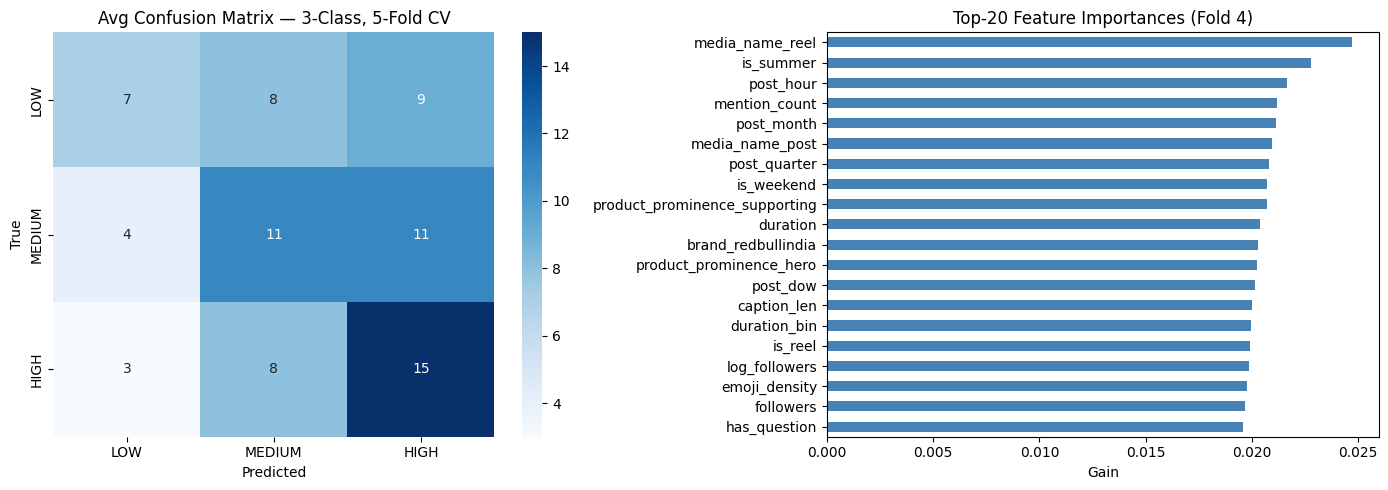

,fold,n_val,acc,f1_weighted,f1_macro
0,0,76,0.434211,0.428459,0.427175
1,1,76,0.460526,0.452454,0.450554
2,2,76,0.434211,0.416792,0.413228
3,3,75,0.453333,0.449138,0.446906
4,4,75,0.386667,0.383140,0.382536


In [20]:
# ── Cell 13: XGBoost 3-Class CV (LOW / MEDIUM / HIGH) ────────────────────────
from sklearn.utils.class_weight import compute_sample_weight

TIER_LABELS = ["LOW", "MEDIUM", "HIGH"]

_defaults = dict(objective="multi:softmax", num_class=3, tree_method="hist",
                 n_estimators=200, max_depth=4, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                 gamma=0.1, reg_alpha=0.1, reg_lambda=1.5,
                 random_state=42, n_jobs=-1)

XGB_PARAMS     = globals().get("OPTUNA_BEST_PARAMS", _defaults)
CUSTOM_WEIGHTS = globals().get("OPTUNA_BEST_WEIGHTS", None)

print(f"Using {'Optuna-tuned' if 'OPTUNA_BEST_PARAMS' in globals() else 'default'} params")
print(XGB_PARAMS)
if CUSTOM_WEIGHTS:
    print(f"Class weights: {CUSTOM_WEIGHTS}")

fold_metrics, all_cms, last_model, last_feat_cols = [], [], None, None

for fold_idx in range(N_FOLDS):
    df_tr = pd.read_parquet(FOLDS_DIR / f"fold_{fold_idx}_train.parquet")
    df_vl = pd.read_parquet(FOLDS_DIR / f"fold_{fold_idx}_val.parquet")

    feat_cols = [c for c in df_tr.columns if c not in ("post_id", "tier", "tier_int")]
    X_tr, y_tr = df_tr[feat_cols].values, df_tr["tier_int"].values
    X_vl, y_vl = df_vl[feat_cols].values, df_vl["tier_int"].values

    if CUSTOM_WEIGHTS:
        sw = np.array([CUSTOM_WEIGHTS[int(y)] for y in y_tr], dtype=float)
    else:
        sw = compute_sample_weight("balanced", y_tr)

    model = xgb.XGBClassifier(**XGB_PARAMS)
    model.fit(X_tr, y_tr, sample_weight=sw)

    preds = model.predict(X_vl)
    acc  = accuracy_score(y_vl, preds)
    f1_w = f1_score(y_vl, preds, average="weighted", zero_division=0)
    f1_m = f1_score(y_vl, preds, average="macro",    zero_division=0)
    cm   = confusion_matrix(y_vl, preds, labels=[0, 1, 2])

    fold_metrics.append({"fold": fold_idx, "n_val": len(y_vl),
                          "acc": acc, "f1_weighted": f1_w, "f1_macro": f1_m})
    all_cms.append(cm)
    last_model, last_feat_cols = model, feat_cols
    print(f"Fold {fold_idx} | n={len(y_vl):3d} | "
          f"acc={acc:.3f}  f1_w={f1_w:.3f}  f1_macro={f1_m:.3f}")

mdf = pd.DataFrame(fold_metrics)
print(f"\n{'─'*60}")
print(f"CV  acc  : {mdf.acc.mean():.3f} ± {mdf.acc.std():.3f}")
print(f"CV  f1_w : {mdf.f1_weighted.mean():.3f} ± {mdf.f1_weighted.std():.3f}")
print(f"CV  f1_m : {mdf.f1_macro.mean():.3f} ± {mdf.f1_macro.std():.3f}")
print(f"Target   : macro-F1 ≥ 0.40  →  {'✓ REACHED' if mdf.f1_macro.mean() >= 0.40 else '✗ not yet'}")

df_vl_last = pd.read_parquet(FOLDS_DIR / f"fold_{N_FOLDS-1}_val.parquet")
y_vl_last  = df_vl_last["tier_int"].values
p_last     = last_model.predict(df_vl_last[last_feat_cols].values)
print(f"\nClassification Report — Fold {N_FOLDS-1}:")
print(classification_report(y_vl_last, p_last, target_names=TIER_LABELS, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_cm = np.round(np.mean(all_cms, axis=0)).astype(int)
sns.heatmap(avg_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=TIER_LABELS, yticklabels=TIER_LABELS, ax=axes[0])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_title(f"Avg Confusion Matrix — 3-Class, {N_FOLDS}-Fold CV")

imp = pd.Series(last_model.feature_importances_, index=last_feat_cols)
imp.nlargest(20).sort_values().plot.barh(ax=axes[1], color="steelblue")
axes[1].set_title(f"Top-20 Feature Importances (Fold {N_FOLDS-1})")
axes[1].set_xlabel("Gain")

plt.tight_layout()
plt.show()

mdf


In [21]:
# ── Cell 14: Save Best CV Model + Train & Save Full-Data Model ───────────────
# Two artefacts:
#   model_cv_best.json   — best fold model (last_model from Cell 13, fold N_FOLDS-1)
#   model_full.json      — retrained on 100% of data with same Optuna params/weights
#   feature_cols.json    — ordered feature list required for inference

import json as _json

MODEL_CV_PATH   = Path("model_cv_best.json")
MODEL_FULL_PATH = Path("model_full.json")
FEAT_COLS_PATH  = Path("feature_cols.json")

# ── 1. Save best CV model ─────────────────────────────────────────────────────
last_model.save_model(str(MODEL_CV_PATH))
print(f"CV model saved  → {MODEL_CV_PATH}")

# ── 2. Persist feature column order for inference ─────────────────────────────
with open(FEAT_COLS_PATH, "w") as fh:
    _json.dump(last_feat_cols, fh)
print(f"Feature list saved → {FEAT_COLS_PATH}  ({len(last_feat_cols)} cols)")

# ── 3. Train final model on 100% of data ─────────────────────────────────────
df_all = pd.read_parquet(OUTPUT_PATH)
feat_cols_all = [c for c in df_all.columns if c not in ("post_id", "tier", "tier_int")]

X_all = df_all[feat_cols_all].values
y_all = df_all["tier_int"].values

# Same class weights discovered by Optuna
sw_all = np.array([CUSTOM_WEIGHTS[int(y)] for y in y_all], dtype=float)

final_model = xgb.XGBClassifier(**XGB_PARAMS)
final_model.fit(X_all, y_all, sample_weight=sw_all)

final_model.save_model(str(MODEL_FULL_PATH))
print(f"Full-data model saved → {MODEL_FULL_PATH}")

# ── 4. Sanity check: in-sample macro-F1 (expected to be optimistic) ───────────
from sklearn.metrics import f1_score as _f1
preds_all = final_model.predict(X_all)
f1_insample = _f1(y_all, preds_all, average="macro", zero_division=0)
print(f"\nIn-sample macro-F1 (full data, optimistic): {f1_insample:.4f}")
print(f"CV macro-F1 (honest estimate)             : {mdf.f1_macro.mean():.4f} ± {mdf.f1_macro.std():.4f}")
print(f"\nArtefacts written:")
print(f"  {MODEL_CV_PATH}   — use for evaluation / comparison")
print(f"  {MODEL_FULL_PATH} — use for production inference")
print(f"  {FEAT_COLS_PATH}  — load this before calling model.predict()")


CV model saved  → model_cv_best.json
Feature list saved → feature_cols.json  (59 cols)
Full-data model saved → model_full.json

In-sample macro-F1 (full data, optimistic): 0.8569
CV macro-F1 (honest estimate)             : 0.4241 ± 0.0277

Artefacts written:
  model_cv_best.json   — use for evaluation / comparison
  model_full.json — use for production inference
  feature_cols.json  — load this before calling model.predict()
